In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report           

In [2]:
data = pd.read_csv(
    r"C:\Sathish\Placement\RESUME\ML\customer_behavior_random_forest_dataset.csv"
)

print(data.head())

  Age_Group Service_Usage Customer_Support_Rating App_Experience  \
0     18-25           Low                    Good            Bad   
1     36-50           Low                    Poor        Average   
2     18-25           Low                    Poor        Average   
3     18-25        Medium                 Average      Excellent   
4     26-35           Low                    Poor            Bad   

  Subscription_Type Complaints  Offer_Response Usage_Frequency  \
0             Basic         No  Not Interested           Daily   
1           Premium        Yes  Not Interested           Daily   
2           Premium        Yes      Interested            Rare   
3             Basic        Yes      Interested            Rare   
4             Basic        Yes      Interested          Weekly   

  Customer_Behavior  
0           Neutral  
1   Likely_To_Leave  
2   Likely_To_Leave  
3           Neutral  
4   Likely_To_Leave  


In [5]:
print(data.info())

print(data.isnull().sum())

NameError: name 'data' is not defined

In [4]:
label_encoder = LabelEncoder()

for column in data.columns:
    data[column] = label_encoder.fit_transform(
        data[column]
    )

print(data.head())

   Age_Group  Service_Usage  Customer_Support_Rating  App_Experience  \
0          0              1                        1               1   
1          2              1                        2               0   
2          0              1                        2               0   
3          0              2                        0               2   
4          1              1                        2               1   

   Subscription_Type  Complaints  Offer_Response  Usage_Frequency  \
0                  0           0               1                0   
1                  1           1               1                0   
2                  1           1               0                1   
3                  0           1               0                1   
4                  0           1               0                2   

   Customer_Behavior  
0                  2  
1                  1  
2                  1  
3                  2  
4                  1  


In [4]:
label_encoder = LabelEncoder()

for column in data.columns:
    data[column] = label_encoder.fit_transform(
        data[column]
    )

print(data.head())

   Age_Group  Service_Usage  Customer_Support_Rating  App_Experience  \
0          0              1                        1               1   
1          2              1                        2               0   
2          0              1                        2               0   
3          0              2                        0               2   
4          1              1                        2               1   

   Subscription_Type  Complaints  Offer_Response  Usage_Frequency  \
0                  0           0               1                0   
1                  1           1               1                0   
2                  1           1               0                1   
3                  0           1               0                1   
4                  0           1               0                2   

   Customer_Behavior  
0                  2  
1                  1  
2                  1  
3                  2  
4                  1  


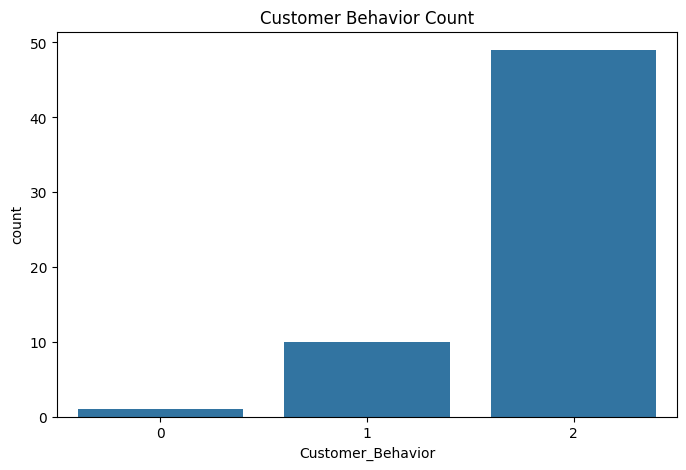

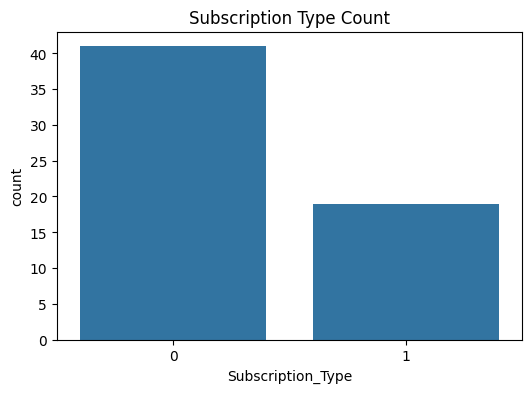

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Customer_Behavior',
    data=data
)

plt.title("Customer Behavior Count")

plt.show()
plt.figure(figsize=(6,4))

sns.countplot(
    x='Subscription_Type',
    data=data
)

plt.title("Subscription Type Count")

plt.show()

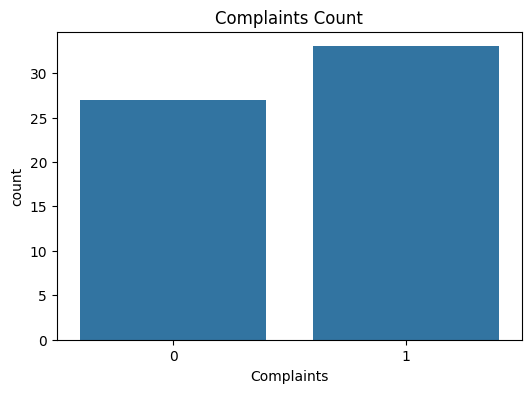

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Complaints',
    data=data
)

plt.title("Complaints Count")

plt.show()

In [9]:
X = data.drop(
    'Customer_Behavior',
    axis=1
)

y = data['Customer_Behavior']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [12]:
model.fit(
    X_train,
    y_train
)

print("Model Training Completed")

Model Training Completed


In [13]:
y_pred = model.predict(X_test)

print(y_pred)

[2 1 2 2 2 2 2 2 2 2 2 2]


In [14]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9166666666666666


In [15]:
report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       0.91      1.00      0.95        10

    accuracy                           0.92        12
   macro avg       0.95      0.75      0.81        12
weighted avg       0.92      0.92      0.90        12



In [19]:
# Sample Customer Data

sample = pd.DataFrame({
    'Age_Group':['26-35'],
    'Service_Usage':['High'],
    'Customer_Support_Rating':['Good'],
    'App_Experience':['Excellent'],
    'Subscription_Type':['Premium'],
    'Complaints':['No'],
    'Offer_Response':['Interested'],
    'Usage_Frequency':['Daily']
})

# Encode Sample Data

sample_encoded = sample.copy()

for column in sample_encoded.columns:

    sample_encoded[column] = label_encoder.fit_transform(
        sample_encoded[column]
    )

# Prediction

prediction = model.predict(sample_encoded)

# Decode Output

if prediction[0] == 0:
    print("Predicted Customer Behavior : Likely_To_Continue")

elif prediction[0] == 1:
    print("Predicted Customer Behavior : Likely_To_Leave")

else:
    print("Predicted Customer Behavior : Neutral")

Predicted Customer Behavior : Neutral
